<a href="https://colab.research.google.com/github/balajiduddukuri/Langchain_practice/blob/Ultimate-Content-Repurposer/langraph_apr_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q openai langchain chromadb faiss-cpu pypdf tiktoken docarray

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.6/21.6 MB 60.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.7/333.7 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.8/302.8 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 54.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 56.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.1/72.1 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.6/231.6 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71

In [ ]:
from google.colab import userdata

OPENAI_API_KEY = userdata.get("api_key")

print("Key loaded successfully")

from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-4o",
    api_key=OPENAI_API_KEY
)

In [ ]:
#NODE

In [ ]:
#EDGE

In [ ]:
#STEP

# LangGrapgh
# AI Agents
# Multi-step wrkflows
# RAG pipelines
# Autonomous Systems

In [5]:
!pip install -q langgraph langchain langchain-openai

In [6]:
from typing import TypedDict
from langgraph.graph import StateGraph, END
from langchain_openai import ChatOpenAI

In [74]:
class MyState(TypedDict):
  topic: str
  explanation: str
  summary: str
  quiz: str

In [8]:
llm = ChatOpenAI(model = "gpt-4o-mini",api_key=OPENAI_API_KEY, temperature = 0.7)

In [78]:
#NODE1:explain

def explain_node(state: MyState):
  response = llm.invoke(f"Explain {state["topic"]} in simple terms")
  return {
      "explanation": response.content
  }

In [79]:
#Node2:summarize
def summarize_node(state: MyState):
  response = llm.invoke(f"Summarize this in 2 lines:\n{state["explanation"]}")
  return {
      "summary": response.content
  }


In [81]:
#Node3:Quiz
def quiz_node(state: MyState):
  response = llm.invoke(f"Quiz me on this with 2 questions:\n{state["explanation"]}")
  return  {
      "quiz": response.content
  }

In [84]:
graph = StateGraph(MyState)

graph.add_node("explain", explain_node)
graph.add_node("summarize", summarize_node)
graph.add_node("quiz", quiz_node)

graph.set_entry_point("explain")
graph.add_edge("explain", "summarize")
graph.add_edge("summarize", "quiz")
graph.add_edge("quiz", END)

In [85]:
app = graph.compile()

In [86]:
result = app.invoke({
    "topic": "Transformers"
})

print("\nExplanation:\n", result["explanation"])
print("\nSummary:\n", result["summary"])
print("\nquiz:\n", result["quiz"])


quiz:
 Here are two quiz questions based on the information you provided about transformers:

1. **What is the main feature of transformers that allows them to focus on different parts of the input text when making predictions?**  
   A) Parallel Processing  
   B) Attention Mechanism  
   C) Multi-layer Structure  
   D) Language Translation  

2. **How do transformers process text compared to older models?**  
   A) One word at a time  
   B) One sentence at a time  
   C) Simultaneously looking at all words in a sentence  
   D) Using only the first and last words of a sentence  

Feel free to answer these questions!


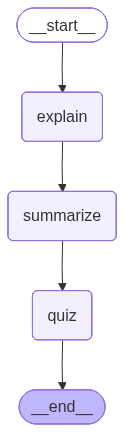

In [87]:
from IPython.display import Image, display

# Assuming 'app' is already compiled from previous steps
display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
#@haystack, @Autogen, @crewai

In [ ]:
#conditional routing